  # Uso de redes generativas para la mejora de la señal astronómica



 El presente "notebook" documenta la extracción y emparejamiento de los datos de Gaia y SDSS.



 Puesto que SDSS tiene menos datos con espectrografía que los que proporciona el crossmatch de Gaia, para mostrar los gráficos usaremos un ejemplo aleatorio de SDSS para mostrar la misma espectrometría para ese objeto en Gaia.cÑw



 El procedimiento será el siguiente:

 1. De Gaia, obtener los mejores crossmatches de Gaia y SDSS

 2. De SDSS, obtener la referencia de la tabla de SDSS con la espectrometría (SpecObj)

 3. De SDSS, seleccionar un ejemplo aleatorio

 4. De SDSS, obtener la espectrometría para el ejemplo obtenido en 3.

 5. De Gaia, obtener la espectrometría para el objeto obtenido en 3.

 6. De Gaia y SDSS, mostrar los gráficos para el objecto obtenido en 3

 ## Extracción de los datos

 ### Obtención de una muestra de objetos

  #### Crossmatches Gaia SDSS

  Se seleccionan aleatoriamente los mejores crossmatches entre Gaia y SDSS.

In [1]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")
gaia_query = gaia_query_template.format(start_index=10000, end_index=20000)

print(f"Executing Step 1: {gaia_query_path.name}...")
gaia_query_job = Gaia.launch_job_async(gaia_query)
gaia_job_results = gaia_query_job.get_results() or Table()

display(gaia_job_results)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Executing Step 1: gaia_sdss_random_subset.adql...
INFO: Query finished. [astroquery.utils.tap.core]


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
511772600594823808,28.824389004290094,62.78104040054845,16.648876,14.946646,1237671067929085095,0.096024014
2113908106237881856,272.28617632709074,42.36153321071573,17.952559,16.47428,1237668735219597934,0.035358556
2853181585444064640,0.8839054612350449,25.553164521492555,17.727354,15.685123,1237663233916862664,0.17601159
3213232061122601216,76.11931761243419,-3.0462870497886123,10.866861,9.742482,1237674285390692486,0.10429026
4233135572419271936,308.66954347934717,3.4767450750268276,16.96263,16.065405,1237669761711473267,0.03420494
4570190282095132544,260.7431087875074,24.34750522793326,14.580609,13.454587,1237659326574559292,0.104074486
521506787488039040,30.124890266987904,69.27781425864383,16.165876,14.465462,1237670446764458167,0.055152655
1268128990096214528,224.07617894120722,25.940884095818586,15.247045,13.890908,1237665351320338448,0.027332427


  #### SDSS - Datos de referencia de objetos

In [2]:
from astroquery.sdss import SDSS
from astropy.io import ascii
from astropy.table import Table
import services.querying as sq

gaia_crossmatch_ids = gaia_job_results["original_ext_source_id"]
query_filter_ids = ",".join(gaia_crossmatch_ids.astype(str))

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)
sdss_query = sdss_query_template_sanitized.format(filter_ids=query_filter_ids)

sdss_query_result = SDSS.query_sql(sdss_query, data_release=13)

display(sdss_query_result)



bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821


  ### Obtención de los datos de espectrometría

  #### SDSS - Selección ejemplo aleatorio

In [3]:
import random as rnd

sdss_sample_object = rnd.choice(sdss_query_result)

display(sdss_sample_object)


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821


 #### SDSS - Espectrometría para el ejemplo

In [4]:

sdss_spectra_response = (
    SDSS.get_spectra(
        plate=sdss_sample_object["plate"],
        mjd=sdss_sample_object["mjd"],
        fiberID=sdss_sample_object["fiberID"],
        data_release=13,
    )
    or []
)

# help(sdss_spectra_response)
# dir(sdss_spectra_response)
# print(sdss_spectra_response)

sdss_fits_file = sdss_spectra_response[0]
sdss_spectra_hdu = sdss_fits_file[
    1
]  # La primera tabla después de la cabecera contiene los datos
sdss_spectra_data = sdss_spectra_hdu.data

display(sdss_spectra_data)


FITS_rec([( 81.29899 , 3.5812, 0.04646247, 0, 0, 1.2230496, 5.8091984,  93.92718 ),
          ( 67.461044, 3.5813, 0.05017509, 0, 0, 1.2226895, 5.711038 ,  83.61908 ),
          ( 73.47311 , 3.5814, 0.05019679, 0, 0, 1.2226721, 5.6385393,  76.660225),
          ...,
          (241.39644 , 3.9634, 0.0450016 , 0, 0, 0.6291565, 4.39943  , 228.70782 ),
          (235.98206 , 3.9635, 0.04643103, 0, 0, 0.6291869, 4.470601 , 228.69785 ),
          (234.06825 , 3.9636, 0.0460658 , 0, 0, 0.628892 , 4.6082253, 228.68784 )],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4')]))

 #### Gaia - Espectrometría para el ejemplo

 Obtenemos la referencia en Gaia para el objecto de muestra de SDSS

In [5]:
gaia_sample_object = gaia_job_results[
    gaia_job_results["original_ext_source_id"] == sdss_sample_object["bestObjID"]
]

display(gaia_sample_object)

gaia_sample_object_source_id = gaia_sample_object["source_id"].item()

display(type(gaia_sample_object_source_id))
display(gaia_sample_object_source_id)


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
1265515347877933440,222.2748877964174,22.198160757624645,15.615676,14.312463,1237665548892766297,0.047822446


int

1265515347877933440

In [11]:
%pip install --upgrade astropy specutils

Note: you may need to restart the kernel to use updated packages.


 Y obtenemos la espctrometría para esa referencia.

In [6]:
import gaiaxpy
import astropy.units as u
from specutils import Spectrum

# 1. Calibrate functionally using gaiaxpy
source_ids = [gaia_sample_object_source_id]
calibrated_spectra, sampling_grid = gaiaxpy.calibrate(source_ids)

# 2. Extract arrays and attach Astropy units
flux_array = calibrated_spectra["flux"].iloc[0]
wavelength_qty = sampling_grid * u.nm
flux_qty = flux_array * (u.W / (u.m**2 * u.nm))

# 3. Instantiate the standard specutils Spectrum1D object
gaia_object_spectrum = Spectrum(flux=flux_qty, spectral_axis=wavelength_qty)

display(gaia_object_spectrum)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


<Spectrum(flux=[1.1738798685109856e-16 ... 1.0551481814690076e-16] W / (nm m2) (shape=(343,), mean=0.00000 W / (nm m2)); spectral_axis=<SpectralAxis [ 336.  338.  340. ... 1016. 1018. 1020.] nm> (length=343))>

 ### Gráficos comparativos

 #### SDSS - Flujo y Longitud de Onda para una objeto

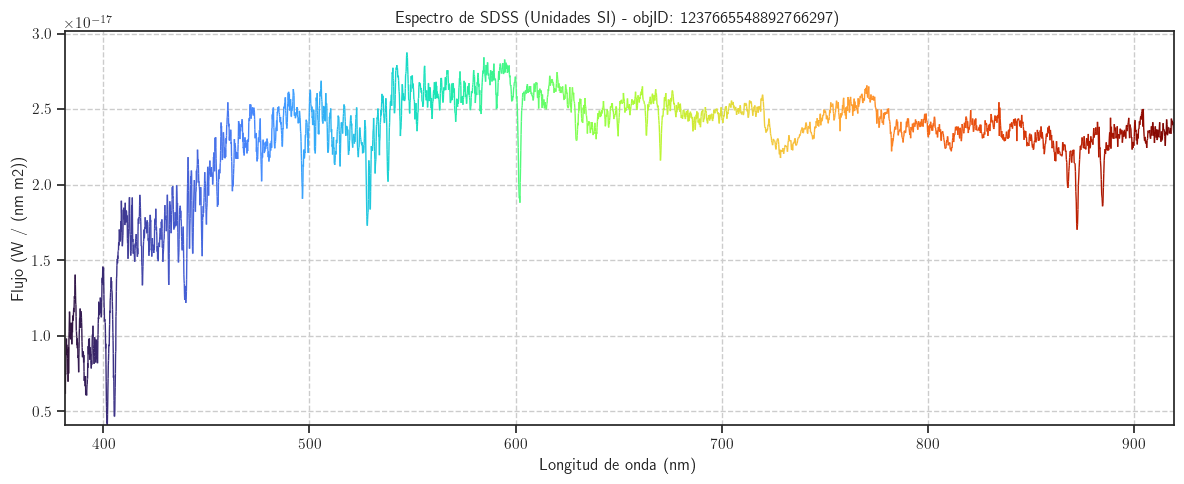

In [7]:
from services.sdss import parse_to_si
from services.plotting import plot_physical_spectrum

wavelength = sdss_spectra_data["loglam"]
flux = sdss_spectra_data["flux"]

sdss_spectrum_si = parse_to_si(wavelength, flux)

plot_physical_spectrum(
    spectrum=sdss_spectrum_si,
    title=f"Espectro de SDSS (Unidades SI) - objID: {sdss_sample_object['bestObjID']})",
)



 #### Gaia - Flujo y Longitud de Onda para una objeto

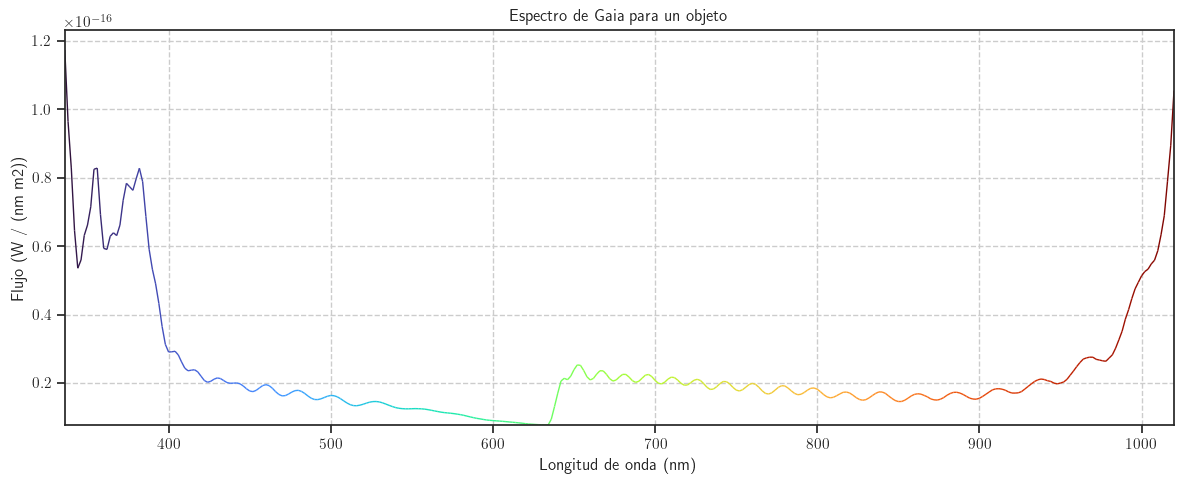

In [8]:
import services.plotting as spl
from specutils import Spectrum
import astropy.units as u

spl.plot_physical_spectrum(
    spectrum=gaia_object_spectrum, title="Espectro de Gaia para un objeto"
)

# # %% [markdown]
# # #### Gaia - Flujo y Longitud de Onda para múltiples objetos

# # %%
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# df = pd.concat(
#     [
#         v[0].to_table().to_pandas().assign(source=key.split()[-1].replace(".xml", ""))
#         for key, v in gaia_spectra_data.items()
#     ],
#     ignore_index=True,
# )

# sns.lineplot(data=df, x="wavelength", y="flux", hue="source")
# plt.show()


Extraer los datos de Gaia en diversas llamadas

In [25]:
from pathlib import Path
from astroquery.gaia import Gaia
from astropy.table import Table, vstack
import time

gaia_query_path = Path("services", "queries", "gaia_sdss_random_subset.adql")
gaia_query_template = gaia_query_path.read_text(encoding="utf-8")

# Configuración de rangos
start = 0
end = 100000
step = 10000

random_ranges = [
    (i, i + step)
    for i in range(start, end, step)
]

gaia_results_list = []

for start_index, end_index in random_ranges:
    print(f"Ejecutando Gaia query para random_index {start_index} - {end_index}...")

    gaia_query = gaia_query_template.format(start_index=start_index, end_index=end_index)

    try:
        gaia_query_job = Gaia.launch_job_async(gaia_query)
        result = gaia_query_job.get_results()

        if result is not None and len(result) > 0:
            print(f"  Objetos obtenidos: {len(result)}")
            gaia_results_list.append(result)
        else:
            print("  No se obtuvieron resultados en este rango.")

    except Exception as e:
        print(f"  Error en el rango {start_index}-{end_index}: {e}")

    time.sleep(1)

if len(gaia_results_list) > 0:
    gaia_job_results = vstack(gaia_results_list)
else:
    gaia_job_results = Table()

print(f"\nTotal de objetos Gaia recolectados: {len(gaia_job_results)}")

display(gaia_job_results)

Ejecutando Gaia query para random_index 0 - 10000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 131
Ejecutando Gaia query para random_index 10000 - 20000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 141
Ejecutando Gaia query para random_index 20000 - 30000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 160
Ejecutando Gaia query para random_index 30000 - 40000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 136
Ejecutando Gaia query para random_index 40000 - 50000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 123
Ejecutando Gaia query para random_index 50000 - 60000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 132
Ejecutando Gaia query para random_index 60000 - 70000...
INFO: Query finished. [astroquery.utils.tap.core]
  Objetos obtenidos: 125
Ejecutando Gaia query para random_index 70000 - 80000...
INFO: Query finished. [

source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance
,deg,deg,mag,mag,,arcsec
int64,float64,float64,float32,float32,int64,float32
284595807324018944,77.01471410515663,60.11782791540674,18.248955,16.47685,1237667206744507270,0.03732705
1154406914752006144,222.59007607238283,2.3425861832919885,17.853062,16.53074,1237651736849350806,0.038843654
3033376732198466432,113.55278552146389,-13.228812451430889,15.485461,14.208205,1237676676615898394,0.034185585
4299240895847854208,300.95065510348076,9.36235866814672,17.626791,16.579626,1237666210333197987,0.02349157
152075175521731328,65.72831483785296,26.54414677239031,17.397339,15.67181,1237660553838723452,0.09896018
1802312382146914944,304.44372864097727,11.814212331449525,17.850197,16.73824,1237666428280047734,0.051741824
3064808054479978496,126.70788872449542,-6.428045792609196,17.280102,16.331446,1237673708252037535,0.074501015
3326210827953204736,97.62465009763454,8.073994072482016,17.689917,16.489973,1237674284864374364,0.04954242


In [26]:
# Función para dividir la lista en bloques de 250 (para que SDSS nos deje acceder)
def chunk_list(values, chunk_size=250):
    """
    Divide una lista en bloques de tamaño máximo chunk_size.
    """
    for i in range(0, len(values), chunk_size):
        yield values[i:i + chunk_size]

In [29]:
import numpy as np

sdss_crossmatch_ids = gaia_job_results["original_ext_source_id"]

# Convertimos a enteros/strings y eliminamos valores nulos si los hubiera
sdss_crossmatch_ids = [
    str(x)
    for x in sdss_crossmatch_ids
    if x is not None and str(x) != "" and str(x).lower() != "nan"
]

print(f"Total de IDs SDSS a consultar: {len(sdss_crossmatch_ids)}")

Total de IDs SDSS a consultar: 1377


In [30]:
from pathlib import Path
from astroquery.sdss import SDSS
from astropy.table import Table, vstack
import services.querying as sq
import time

sdss_query_path = Path("services", "queries", "sdss.adql")
sdss_query_template = sdss_query_path.read_text(encoding="utf-8")
sdss_query_template_sanitized = sq.sanitize_adql(sdss_query_template)

chunk_size = 250

sdss_results_list = []

id_chunks = list(chunk_list(sdss_crossmatch_ids, chunk_size=chunk_size))

print(f"Número de bloques SDSS a consultar: {len(id_chunks)}")

for chunk_number, ids_chunk in enumerate(id_chunks, start=1):
    print(
        f"Consultando bloque {chunk_number}/{len(id_chunks)} "
        f"con {len(ids_chunk)} IDs..."
    )

    query_filter_ids = ",".join(ids_chunk)

    sdss_query = sdss_query_template_sanitized.format(
        filter_ids=query_filter_ids
    )

    try:
        result = SDSS.query_sql(
            sdss_query,
            data_release=13
        )

        if result is not None and len(result) > 0:
            print(f"  Objetos SDSS encontrados: {len(result)}")
            sdss_results_list.append(result)
        else:
            print("  No se encontraron objetos SDSS en este bloque.")

    except Exception as e:
        print(f"  Error en bloque {chunk_number}: {e}")

    # Pausa para no saturar el servicio
    time.sleep(1)


if len(sdss_results_list) > 0:
    sdss_query_result = vstack(sdss_results_list)
else:
    sdss_query_result = Table()

print(f"\nTotal de objetos SDSS encontrados: {len(sdss_query_result)}")

display(sdss_query_result)

Número de bloques SDSS a consultar: 6
Consultando bloque 1/6 con 250 IDs...
  Objetos SDSS encontrados: 2
Consultando bloque 2/6 con 250 IDs...
  Objetos SDSS encontrados: 3
Consultando bloque 3/6 con 250 IDs...
  Objetos SDSS encontrados: 4
Consultando bloque 4/6 con 250 IDs...
  Objetos SDSS encontrados: 3
Consultando bloque 5/6 con 250 IDs...
  Objetos SDSS encontrados: 5
Consultando bloque 6/6 con 127 IDs...
  Objetos SDSS encontrados: 1

Total de objetos SDSS encontrados: 18


bestObjID,specObjID,plate,mjd,fiberID,redshift
int64,uint64,int64,int64,int64,float64
1237665548892766297,2413980315933501440,2144,53770,185,0.02115821
1237678617406210404,3542239791556960256,3146,54773,577,-0.000279155
1237662300827877635,1887059698834761728,1676,53147,187,1.22274
1237666209782563492,2459015758491969536,2184,53534,183,-0.0002618367
1237671142546342036,3028764553421809664,2690,54211,341,0.0003355562
1237656495653847070,3600701101227220992,3198,54865,266,-0.0005022312
1237658630769082409,1818439178464028672,1615,53166,403,0.0004315955
1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833
1237678617434718210,4216670061287313408,3745,55234,636,2.520728


In [31]:
from astropy.table import join, Table

# Guardamos referencias comunes

gaia_sdss_common = join(
    gaia_job_results,
    sdss_query_result,
    keys_left="original_ext_source_id",
    keys_right="bestObjID",
    join_type="inner"
)

print(f"Objetos comunes Gaia-SDSS: {len(gaia_sdss_common)}")

display(gaia_sdss_common)

Objetos comunes Gaia-SDSS: 18


source_id,ra,dec,phot_bp_mean_mag,phot_rp_mean_mag,original_ext_source_id,angular_distance,bestObjID,specObjID,plate,mjd,fiberID,redshift
,deg,deg,mag,mag,,arcsec,,,,,,
int64,float64,float64,float32,float32,int64,float32,int64,uint64,int64,int64,int64,float64
857539664310198272,169.80555827533604,58.68186191158194,17.919144,17.06511,1237655107837689867,0.09361063,1237655107837689867,2695447059409954816,2394,54551,155,-0.0002362201
1308974472679778304,257.45075277225425,29.57907119791902,17.45626,15.876958,1237655472900211268,0.02533424,1237655472900211268,5626168110249545728,4997,55738,168,-8.493909e-05
2780126940517565824,7.795212008276678,15.025624611570457,17.151657,16.16204,1237656495653847070,0.08788732,1237656495653847070,3600701101227220992,3198,54865,266,-0.0005022312
3907992224394950528,187.14389337206893,13.069695640238544,16.89181,16.234444,1237658630769082409,0.009881143,1237658630769082409,1818439178464028672,1615,53166,403,0.0004315955
1589762907457297280,228.47946990984158,50.97969443927994,16.189617,15.30423,1237659149387563016,0.067105286,1237659149387563016,3712144852314595328,3297,54941,192,-0.000235833
3740380472833279616,206.04014034592456,12.687205318815103,16.76297,16.080265,1237661818176667652,0.033878293,1237661818176667652,1915244579817285632,1701,53142,323,0.000117557
1585715325981468928,224.83771784388213,43.95493339834955,18.701752,18.239342,1237662300827877635,0.043313846,1237662300827877635,1887059698834761728,1676,53147,187,1.22274
1181566776103324672,223.21981644832076,12.501513154207483,16.828114,14.305894,1237662530606858510,0.02884606,1237662530606858510,3837186262545047552,3408,54948,434,-0.0001137369


In [32]:
xp_rows = []
xp_log = []

source_ids = [
    str(x)
    for x in gaia_sdss_common["source_id"]
]
source_id_chunks = list(chunk_list(source_ids, chunk_size=chunk_size))

print(f"Número de bloques XP_CONTINUOUS a consultar: {len(source_id_chunks)}")

for chunk_number, ids_chunk in enumerate(source_id_chunks, start=1):
    print(
        f"Consultando XP_CONTINUOUS bloque {chunk_number}/{len(source_id_chunks)} "
        f"con {len(ids_chunk)} objetos..."
    )

    ids_text = ",".join(ids_chunk)

    try:
        gaia_spectra_data = Gaia.load_data(
            ids=ids_text,
            data_release="Gaia DR3",
            retrieval_type="XP_CONTINUOUS",
            data_structure="INDIVIDUAL",
            format="votable",
            dump_to_file=False,
        )

        print(f"  Productos recibidos: {len(gaia_spectra_data)}")

        for key, product_list in gaia_spectra_data.items():
            try:
                table = product_list[0].to_table()

                # Normalmente XP_CONTINUOUS devuelve una fila por fuente
                row = table[0]

                # Localizar source_id
                source_id = str(row["source_id"])

                # Extraer coeficientes
                bp_coefficients = list(row["bp_coefficients"])
                rp_coefficients = list(row["rp_coefficients"])

                xp_rows.append({
                    "source_id": source_id,
                    "bp_coefficients": bp_coefficients,
                    "rp_coefficients": rp_coefficients,
                })

                xp_log.append({
                    "source_id": source_id,
                    "status": "ok",
                    "message": "",
                })

            except Exception as e:
                xp_log.append({
                    "source_id": str(key),
                    "status": "error_product",
                    "message": str(e),
                })

                print(f"  Error procesando producto {key}: {e}")

    except Exception as e:
        print(f"  Error en bloque {chunk_number}: {e}")

        for sid in ids_chunk:
            xp_log.append({
                "source_id": sid,
                "status": "error_block",
                "message": str(e),
            })

    time.sleep(2)

print(f"\nTotal objetos con coeficientes XP extraídos: {len(xp_rows)}")

Número de bloques XP_CONTINUOUS a consultar: 1
Consultando XP_CONTINUOUS bloque 1/1 con 18 objetos...
  Productos recibidos: 18

Total objetos con coeficientes XP extraídos: 18


In [ ]:
from astroquery.gaia import Gaia

source_ids = "857539664310198272"

gaia_spectra_data = Gaia.load_data(
    ids=source_ids,
    data_release="Gaia DR3",
    retrieval_type="XP_CONTINUOUS",
    data_structure="INDIVIDUAL",
    format="votable",
    dump_to_file=False,
)

table = list(gaia_spectra_data.values())[0][0].to_table()

print(table.colnames)
display(table)

['source_id', 'solution_id', 'bp_basis_function_id', 'bp_degrees_of_freedom', 'bp_n_parameters', 'bp_n_measurements', 'bp_n_rejected_measurements', 'bp_standard_deviation', 'bp_chi_squared', 'bp_coefficients', 'bp_coefficient_errors', 'bp_coefficient_correlations', 'bp_n_relevant_bases', 'bp_relative_shrinking', 'rp_basis_function_id', 'rp_degrees_of_freedom', 'rp_n_parameters', 'rp_n_measurements', 'rp_n_rejected_measurements', 'rp_standard_deviation', 'rp_chi_squared', 'rp_coefficients', 'rp_coefficient_errors', 'rp_coefficient_correlations', 'rp_n_relevant_bases', 'rp_relative_shrinking']


source_id,solution_id,bp_basis_function_id,bp_degrees_of_freedom,bp_n_parameters,bp_n_measurements,bp_n_rejected_measurements,bp_standard_deviation,bp_chi_squared,bp_coefficients,bp_coefficient_errors,bp_coefficient_correlations,bp_n_relevant_bases,bp_relative_shrinking,rp_basis_function_id,rp_degrees_of_freedom,rp_n_parameters,rp_n_measurements,rp_n_rejected_measurements,rp_standard_deviation,rp_chi_squared,rp_coefficients,rp_coefficient_errors,rp_coefficient_correlations,rp_n_relevant_bases,rp_relative_shrinking
int64,int64,int16,int16,int16,int16,int16,float32,float32,object,object,object,int16,float32,int16,int16,int16,int16,int16,float32,float32,object,object,object,int16,float32
857539664310198272,4545469030156206080,56,2372,55,2427,13,1.0476779,2603.576,[112.17718638553211 -20.004034561446957 1.6414705040290059\n 0.20061352869702664 -0.5689898488666981 0.17911262473702977\n 0.2398990441597901 -0.14423226806076367 -0.21507560997581637\n 0.17268420888692934 -0.3141624129503299 0.18644234311800872\n -0.4356966810220865 0.40026371623279555 0.6195408454529082\n 0.22536987288912003 0.001762275675609602 -0.20161876445076837\n -0.2995185592052869 0.15766135420964572 -0.12390834982180293\n -0.2007824162550515 0.08125430665919603 -0.26660558935224304\n -0.2465538345536965 0.5059150955135275 -0.2544263631491839\n 0.27159344185050877 0.012943982724467255 -0.5510431610967998\n 0.2726481117488229 0.07146103036183821 0.24943956056350197\n 0.20012061862673225 -0.24638898403400084 -0.05823109993924596\n -0.05328680037684118 0.4689665966091604 0.06193001779502117\n -0.1549728830320758 -0.1272416054483834 -0.23436313598884442\n -0.03345086550121329 0.49020725829531353 0.10914221815774197\n 0.08942310684659076 0.1272524720537308 0.14593528521505564\n 0.06734717152739732 -0.2964782659236535 -0.03135878721232965\n -0.0030618449055193897 0.0702850781140679 0.0654059992783707\n 0.03208884729333142],[0.3883494734764099 0.3457973301410675 0.3505985736846924\n 0.36094704270362854 0.37776556611061096 0.33192798495292664\n 0.30703112483024597 0.8613800406455994 0.43805718421936035\n 0.33317604660987854 0.4026011526584625 0.37905240058898926\n 0.3357831835746765 0.38816240429878235 0.4031641483306885\n 0.35254886746406555 0.31088703870773315 0.2848069369792938\n 0.2986322045326233 0.2491796463727951 0.3145340085029602\n 0.27956321835517883 0.28729480504989624 0.27339616417884827\n 0.2666023075580597 0.2534906566143036 0.24612784385681152\n 0.21954119205474854 0.2363639622926712 0.20324209332466125\n 0.22521954774856567 0.24008774757385254 0.22079122066497803\n 0.21219561994075775 0.2007419764995575 0.21089263260364532\n 0.20093783736228943 0.20059441030025482 0.1929468810558319\n 0.19837309420108795 0.18977952003479004 0.18784672021865845\n 0.18689851462841034 0.17242838442325592 0.1494211107492447\n 0.15171833336353302 0.1502382457256317 0.13203313946723938\n 0.11827364563941956 0.08896704763174057 0.0871613398194313\n 0.06946495175361633 0.05786988139152527 0.05074338614940643\n 0.02188706211745739],[0.10361111909151077 -0.11211322247982025 0.10326191782951355 ...\n -0.016673048958182335 -0.049049507826566696 0.05929327383637428],50,0.9999996,57,3407,55,3462,17,1.0517843,3768.9941,[112.81041505883445 -15.690157572295119 -0.5060360335559573\n 0.09666210710031671 0.06616288031117219 -0.8012695643197629\n -0.08652003115092105 -0.08161573460426362 -0.1765875897558147\n 0.5281710555361637 -0.15701076298484531 0.1980119176625092\n -0.23381035834852157 0.6357004571498771 -0.5703418156733486\n 0.26835032065765557 -0.17418379128804423 -0.14112555112937136\n 0.24386906645934442 -0.19001924697282718 0.549411823398559\n -0.5280358226855686 -0.20030055053668083 -0.15517291547064715\n 0.1905273169158619 0.02440918644779636 -0.19689295356404624\n 0.14945139903904237 -0.01156375315137241 -0.1358275428873948\n -0.04332559512395301 0.03948374625182311 0.10808664378465584\n 0.29131074323265893 -0.11019591422813872 0.006569242138235648\n -0.05758828303024169 0.014685